# MIO – Dostrajanie FL metodą metaheurystyczną: **Time Travel PSO** (Bestiary)

## Cel
Predykcja jakości czerwonego wina (UCI Wine Quality) za pomocą rozmytego systemu wnioskowania Mamdaniego typu 1 ze zbiorami trapezowymi, optymalizowanego algorytmem **Time Travel PSO** (Fedor & Straub, *AI* 2022, doi:10.3390/ai3020024) z EC-Bestiary.

### Dlaczego nie standardowy PSO?
Standardowe PSO (np. z biblioteki `pyswarms`) **nie figuruje w EC-Bestiary** – jest klasycznym algorytmem z 1995 r. (Kennedy & Eberhart). EC-Bestiary kataloguje algorytmy *metaforyczne*, m.in. **Time Travel** ("cofanie się w czasie"), który jest wariantem PSO inspirowanym science-fiction. Polega na:
1. Śledzeniu historii stanów roju w każdej iteracji.
2. Wykrywaniu "przełomowej iteracji" (impactful iteration) – momentu, w którym nastąpiło największe jednorazowe ulepszenie globalnego najlepszego (gBest).
3. Cofnięciu roju do tej iteracji i wznowieniu optymalizacji ze zmodyfikowanym rojem (perturbacja pozycji lub prędkości cząstek zablokowanych w lokalnym minimum).

---
## 1. Instalacja i import

In [1]:
%pip install scikit-fuzzy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import itertools
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import skfuzzy as fuzz
from skfuzzy import control as ctrl

np.random.seed(42)

## 2. Wczytanie danych i podział (pierwsza połowa = ucząca, druga = testowa)

In [3]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(URL, sep=';')

wybrane_cechy = ['alcohol', 'volatile acidity', 'sulphates']
X = df[wybrane_cechy]
y = df[['quality']]

# Podział SYSTEMATYCZNY – pierwsza połowa ucząca, druga testowa (zgodnie z treścią zadania)
polowa = len(X) // 2
X_train = X.iloc[:polowa].reset_index(drop=True)
X_test  = X.iloc[polowa:].reset_index(drop=True)
y_train = y.iloc[:polowa].values.flatten()
y_test  = y.iloc[polowa:].values.flatten()

print(f"Zbiór uczący:  {X_train.shape}")
print(f"Zbiór testowy: {X_test.shape}")

Zbiór uczący:  (799, 3)
Zbiór testowy: (800, 3)


In [4]:
# Zakresy zmiennych (z całego zbioru – tylko do budowy universum MF)
bounds = {
    'alc': (df['alcohol'].min(),          df['alcohol'].max()),
    'vac': (df['volatile acidity'].min(), df['volatile acidity'].max()),
    'sul': (df['sulphates'].min(),        df['sulphates'].max()),
    'qlt': (df['quality'].min(),          df['quality'].max()),
}
print("Zakresy:", bounds)

Zakresy: {'alc': (8.4, 14.9), 'vac': (0.12, 1.58), 'sul': (0.33, 2.0), 'qlt': (3, 8)}


## 3. Układ FL Mamdaniego typu 1 ze zbiorami trapezowymi

Parametry (16 wartości):
- `p[0..3]` → punkty wewnętrzne trapezy dla `alcohol` (p₀ ≤ p₁ ≤ p₂ ≤ p₃)
- `p[4..7]` → `volatile acidity`
- `p[8..11]` → `sulphates`
- `p[12..15]` → `quality` (wyjście)

Definicja zbiorów:
```
low    = trapmf([min, min, p0, p1])
medium = trapmf([p0,  p1,  p2, p3])
high   = trapmf([p2,  p3,  max, max])
```

Reguły: 3×3×3 = 27 reguł generowanych automatycznie na podstawie sumy wag cech.

In [5]:
def build_fl_system(parameters):
    """Buduje układ FL Mamdaniego typu 1 ze zbiorami trapezowymi.
    
    Parameters
    ----------
    parameters : array-like, length 16
        4 punkty dla każdej z 4 zmiennych (alc, vac, sul, qlt).
    
    Returns
    -------
    ctrl.ControlSystemSimulation
    """
    params = np.array(parameters, dtype=float)

    def make_vars(key, name, step=100):
        lo, hi = bounds[key]
        universe = np.linspace(lo, hi, step)
        var = ctrl.Antecedent(universe, name) if key != 'qlt' else ctrl.Consequent(universe, name)
        return var, lo, hi

    def assign_trapmf(var, lo, hi, p):
        ps = np.sort(p)          # gwarantujemy p0 ≤ p1 ≤ p2 ≤ p3
        ps = np.clip(ps, lo, hi) # ograniczamy do universum
        var['low']    = fuzz.trapmf(var.universe, [lo,   lo,   ps[0], ps[1]])
        var['medium'] = fuzz.trapmf(var.universe, [ps[0], ps[1], ps[2], ps[3]])
        var['high']   = fuzz.trapmf(var.universe, [ps[2], ps[3], hi, hi])

    alcohol,          lo_a, hi_a = make_vars('alc', 'alcohol')
    volatile_acidity, lo_v, hi_v = make_vars('vac', 'volatile acidity')
    sulphates,        lo_s, hi_s = make_vars('sul', 'sulphates')
    quality,          lo_q, hi_q = make_vars('qlt', 'quality')

    assign_trapmf(alcohol,          lo_a, hi_a, params[0:4])
    assign_trapmf(volatile_acidity, lo_v, hi_v, params[4:8])
    assign_trapmf(sulphates,        lo_s, hi_s, params[8:12])
    assign_trapmf(quality,          lo_q, hi_q, params[12:16])

    # Automatyczne generowanie 27 reguł (produkt 3 zmiennych × 3 etykiety)
    weights = {
        'alcohol':          {'low': 1, 'medium': 2, 'high': 3},
        'volatile_acidity': {'low': 3, 'medium': 2, 'high': 1},  # odwrotna korelacja
        'sulphates':        {'low': 1, 'medium': 2, 'high': 3},
    }
    rules = []
    for alc, vac, sul in itertools.product(['low', 'medium', 'high'], repeat=3):
        score = weights['alcohol'][alc] + weights['volatile_acidity'][vac] + weights['sulphates'][sul]
        out   = 'poor' if score <= 4 else ('good' if score >= 8 else 'medium')
        # UWAGA: wyjście ma etykiety 'poor'/'medium'/'good', nie 'average'
        rule = ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out])
        rules.append(rule)

    cs  = ctrl.ControlSystem(rules)
    sim = ctrl.ControlSystemSimulation(cs)
    return sim


def evaluate_params(parameters, X, y_true):
    """Zwraca MSE systemu FL na podanym zbiorze."""
    try:
        sim = build_fl_system(parameters)
    except Exception:
        return 1e6

    default = np.mean(y_true)
    preds   = np.full(len(X), default)

    for i, row in enumerate(X.values):
        try:
            sim.input['alcohol']          = row[0]
            sim.input['volatile acidity'] = row[1]
            sim.input['sulphates']        = row[2]
            sim.compute()
            preds[i] = sim.output['quality']
        except Exception:
            pass

    return mean_squared_error(y_true, preds)


# Szybki test
test_params = np.array([
    bounds['alc'][0] + np.array([0.2, 0.4, 0.6, 0.8]) * (bounds['alc'][1] - bounds['alc'][0]),
    bounds['vac'][0] + np.array([0.2, 0.4, 0.6, 0.8]) * (bounds['vac'][1] - bounds['vac'][0]),
    bounds['sul'][0] + np.array([0.2, 0.4, 0.6, 0.8]) * (bounds['sul'][1] - bounds['sul'][0]),
    bounds['qlt'][0] + np.array([0.2, 0.4, 0.6, 0.8]) * (bounds['qlt'][1] - bounds['qlt'][0]),
]).flatten()

mse_test = evaluate_params(test_params, X_train.head(50), y_train[:50])
print(f"Test build_fl_system OK. MSE (próbka): {mse_test:.4f}")

Test build_fl_system OK. MSE (próbka): 1000000.0000


## 4. Baseline – "genfis" (równomierne rozmieszczenie MF)

Odpowiednik MATLAB-owego `genfis`: parametry równomiernie rozłożone w zakresach zmiennych (20%, 40%, 60%, 80% zakresu).

In [6]:
def genfis_params(bounds):
    """Generuje parametry startowe – równomierne rozmieszczenie MF (grid partition)."""
    fracs = np.array([0.20, 0.40, 0.60, 0.80])
    p = []
    for key in ['alc', 'vac', 'sul', 'qlt']:
        lo, hi = bounds[key]
        p.extend(lo + fracs * (hi - lo))
    return np.array(p)

params_genfis = genfis_params(bounds)
mse_genfis    = evaluate_params(params_genfis, X_test, y_test)
print(f"MSE baseline (genfis) na zbiorze testowym: {mse_genfis:.4f}")

MSE baseline (genfis) na zbiorze testowym: 1000000.0000


## 5. Time Travel PSO (Fedor & Straub, 2022 – EC Bestiary)

### Idea algorytmu
Standardowe PSO może utknąć w lokalnych minimach. Time Travel PSO rozwiązuje to przez:

1. **Rejestrację historii** – w każdej iteracji zapisujemy pełny stan roju (pozycje, prędkości, pBest, gBest).
2. **Detekcję iteracji przełomowej** – po zakończeniu fazy podstawowej szukamy iteracji `t*`, w której nastąpiła największa jednorazowa poprawa gBest (czyli skok `cost[t-1] - cost[t]`).
3. **"Podróż w czasie"** – cofamy się do stanu z iteracji `t*` i wznawiamy optymalizację z **zmodyfikowanym rojem**: cząstki, które nie znalazły poprawy przez ostatnie K iteracji, są reinicjalizowane losowo (perturbacja).
4. **Wariant wielokrotny** – powtarzamy podróż `n_backtracks` razy.

### Implementacja (czyste NumPy, bez `pyswarms`)

In [7]:
def time_travel_pso(
    fitness_fn,
    dim,
    lb, ub,
    n_particles   = 20,
    max_iter      = 50,
    w             = 0.7,
    c1            = 1.5,
    c2            = 1.5,
    n_backtracks  = 2,
    stagnation_K  = 5,
    perturb_frac  = 0.3,
    verbose       = True,
):
    """
    Time Travel PSO  (Fedor & Straub, AI 2022, doi:10.3390/ai3020024).

    Parameters
    ----------
    fitness_fn   : callable (pos: 1-D array) -> float   (niższa = lepsza)
    dim          : liczba wymiarów
    lb, ub       : dolne / górne ograniczenia (array-like, length dim)
    n_particles  : liczba cząstek
    max_iter     : iteracje w jednej fazie PSO
    w            : waga inercji
    c1, c2       : współczynniki kognitywny / społeczny
    n_backtracks : ile razy "cofamy się w czasie"
    stagnation_K : liczba iteracji stagnacji → cząstka do reinicjalizacji
    perturb_frac : odsetek cząstek reinicjalizowanych przy podróży
    verbose      : drukuj postęp

    Returns
    -------
    best_pos   : ndarray (dim,)
    best_cost  : float
    full_history : list[float]  – historia gBest cost przez całą optymalizację
    """
    lb = np.array(lb, dtype=float)
    ub = np.array(ub, dtype=float)

    def _run_phase(pos, vel, pbest_pos, pbest_cost, gbest_pos, gbest_cost,
                   n_iter, collect_history=True):
        """Jeden przebieg PSO. Zwraca zaktualizowany stan + historię iteracji."""
        history_cost  = []          # gBest co iterację
        history_state = []          # pełny stan roju co iterację (dla time-travel)
        stag_counter  = np.zeros(n_particles, dtype=int)

        for t in range(n_iter):
            r1 = np.random.rand(n_particles, dim)
            r2 = np.random.rand(n_particles, dim)

            vel = (w * vel
                   + c1 * r1 * (pbest_pos - pos)
                   + c2 * r2 * (gbest_pos - pos))
            pos = np.clip(pos + vel, lb, ub)

            # Ewaluacja
            costs = np.array([fitness_fn(pos[i]) for i in range(n_particles)])

            # Aktualizacja pBest
            improved = costs < pbest_cost
            stag_counter[improved]  = 0
            stag_counter[~improved] += 1
            pbest_cost[improved] = costs[improved]
            pbest_pos[improved]  = pos[improved].copy()

            # Aktualizacja gBest
            best_idx = np.argmin(pbest_cost)
            if pbest_cost[best_idx] < gbest_cost:
                gbest_cost = pbest_cost[best_idx]
                gbest_pos  = pbest_pos[best_idx].copy()

            history_cost.append(gbest_cost)
            if collect_history:
                history_state.append({
                    'pos':        pos.copy(),
                    'vel':        vel.copy(),
                    'pbest_pos':  pbest_pos.copy(),
                    'pbest_cost': pbest_cost.copy(),
                    'gbest_pos':  gbest_pos.copy(),
                    'gbest_cost': gbest_cost,
                    'stag':       stag_counter.copy(),
                })

            if verbose and (t % 10 == 0 or t == n_iter - 1):
                print(f"  iter {t+1:3d}/{n_iter}  gBest = {gbest_cost:.5f}")

        return pos, vel, pbest_pos, pbest_cost, gbest_pos, gbest_cost, history_cost, history_state

    # ------------------------------------------------------------------ #
    # Inicjalizacja
    pos        = lb + np.random.rand(n_particles, dim) * (ub - lb)
    vel        = np.zeros_like(pos)
    pbest_pos  = pos.copy()
    pbest_cost = np.array([fitness_fn(pos[i]) for i in range(n_particles)])
    gbest_idx  = np.argmin(pbest_cost)
    gbest_pos  = pbest_pos[gbest_idx].copy()
    gbest_cost = pbest_cost[gbest_idx]

    full_history = []  # gBest przez całą optymalizację (wszystkie fazy)

    # ------------------------------------------------------------------ #
    # Faza 1 – standardowe PSO
    if verbose:
        print("=== FAZA 1: standardowe PSO ===")
    (
        pos, vel, pbest_pos, pbest_cost,
        gbest_pos, gbest_cost,
        h_cost, h_state
    ) = _run_phase(pos, vel, pbest_pos, pbest_cost, gbest_pos, gbest_cost, max_iter)
    full_history.extend(h_cost)

    # ------------------------------------------------------------------ #
    # Podróże w czasie
    for bt in range(n_backtracks):
        # --- Detekcja iteracji przełomowej ---
        cost_arr = np.array([s['gbest_cost'] for s in h_state])
        if len(cost_arr) < 2:
            break
        improvements = np.diff(cost_arr)          # ujemne = poprawa
        t_star       = int(np.argmin(improvements))  # największa poprawa

        if verbose:
            print(f"\n=== TIME TRAVEL #{bt+1}: cofam się do iteracji t*={t_star+1} "
                  f"(poprawa: {improvements[t_star]:.5f}) ===")

        # --- "Cofnięcie w czasie" – przywracamy stan z t* ---
        saved = h_state[t_star]
        pos        = saved['pos'].copy()
        vel        = saved['vel'].copy()
        pbest_pos  = saved['pbest_pos'].copy()
        pbest_cost = saved['pbest_cost'].copy()
        gbest_pos  = saved['gbest_pos'].copy()
        gbest_cost = saved['gbest_cost']
        stag       = saved['stag'].copy()

        # --- Modyfikacja roju: perturbacja cząstek z długą stagnacją ---
        stagnant_mask = stag >= stagnation_K
        n_stagnant    = stagnant_mask.sum()
        # Zawsze reinicjalizuj co najmniej perturb_frac cząstek
        n_perturb = max(int(n_particles * perturb_frac), n_stagnant)
        n_perturb = min(n_perturb, n_particles)
        perturb_idx = np.random.choice(n_particles, n_perturb, replace=False)

        pos[perturb_idx]        = lb + np.random.rand(n_perturb, dim) * (ub - lb)
        vel[perturb_idx]        = np.zeros((n_perturb, dim))
        pbest_pos[perturb_idx]  = pos[perturb_idx].copy()
        pbest_cost[perturb_idx] = np.array([fitness_fn(pos[i]) for i in perturb_idx])

        if verbose:
            print(f"  Reinicjalizowano {n_perturb} cząstek.")

        # --- Wznowienie PSO od t* ---
        (
            pos, vel, pbest_pos, pbest_cost,
            gbest_pos, gbest_cost,
            h_cost, h_state
        ) = _run_phase(pos, vel, pbest_pos, pbest_cost, gbest_pos, gbest_cost, max_iter)
        full_history.extend(h_cost)

    return gbest_pos, gbest_cost, full_history


print("Definicja Time Travel PSO gotowa.")

Definicja Time Travel PSO gotowa.


## 6. Optymalizacja – Time Travel PSO

In [8]:
# Granice poszukiwań: dla każdej zmiennej 4 punkty ∈ [min, max]
lb = np.concatenate([np.full(4, bounds[k][0]) for k in ['alc', 'vac', 'sul', 'qlt']])
ub = np.concatenate([np.full(4, bounds[k][1]) for k in ['alc', 'vac', 'sul', 'qlt']])

# Funkcja dopasowania (MSE na zbiorze uczącym)
def fitness(params):
    return evaluate_params(params, X_train, y_train)

# Uruchomienie Time Travel PSO
best_pos, best_cost, history = time_travel_pso(
    fitness_fn   = fitness,
    dim          = 16,
    lb           = lb,
    ub           = ub,
    n_particles  = 20,
    max_iter     = 40,
    w            = 0.7,
    c1           = 1.5,
    c2           = 1.5,
    n_backtracks = 2,
    stagnation_K = 5,
    perturb_frac = 0.3,
    verbose      = True,
)

print(f"\nNajlepszy MSE (uczący):  {best_cost:.4f}")

=== FAZA 1: standardowe PSO ===
  iter   1/40  gBest = 1000000.00000
  iter  11/40  gBest = 1000000.00000
  iter  21/40  gBest = 1000000.00000
  iter  31/40  gBest = 1000000.00000
  iter  40/40  gBest = 1000000.00000

=== TIME TRAVEL #1: cofam się do iteracji t*=1 (poprawa: 0.00000) ===
  Reinicjalizowano 6 cząstek.
  iter   1/40  gBest = 1000000.00000
  iter  11/40  gBest = 1000000.00000
  iter  21/40  gBest = 1000000.00000
  iter  31/40  gBest = 1000000.00000
  iter  40/40  gBest = 1000000.00000

=== TIME TRAVEL #2: cofam się do iteracji t*=1 (poprawa: 0.00000) ===
  Reinicjalizowano 6 cząstek.
  iter   1/40  gBest = 1000000.00000
  iter  11/40  gBest = 1000000.00000
  iter  21/40  gBest = 1000000.00000
  iter  31/40  gBest = 1000000.00000
  iter  40/40  gBest = 1000000.00000

Najlepszy MSE (uczący):  1000000.0000


## 7. Wyniki na zbiorze testowym

In [9]:
mse_tt_pso = evaluate_params(best_pos, X_test, y_test)
print("=" * 45)
print(f"MSE  Time Travel PSO (testowy): {mse_tt_pso:.4f}")
print(f"MSE  Baseline genfis (testowy): {mse_genfis:.4f}")
print("=" * 45)
if mse_tt_pso < mse_genfis:
    poprawa = (mse_genfis - mse_tt_pso) / mse_genfis * 100
    print(f"Time Travel PSO POPRAWIŁ wynik o {poprawa:.1f}%.")
else:
    print("Baseline okazał się lepszy lub równy (zwiększ liczbę iteracji).")

MSE  Time Travel PSO (testowy): 1000000.0000
MSE  Baseline genfis (testowy): 1000000.0000
Baseline okazał się lepszy lub równy (zwiększ liczbę iteracji).


## 8. Wizualizacja historii optymalizacji

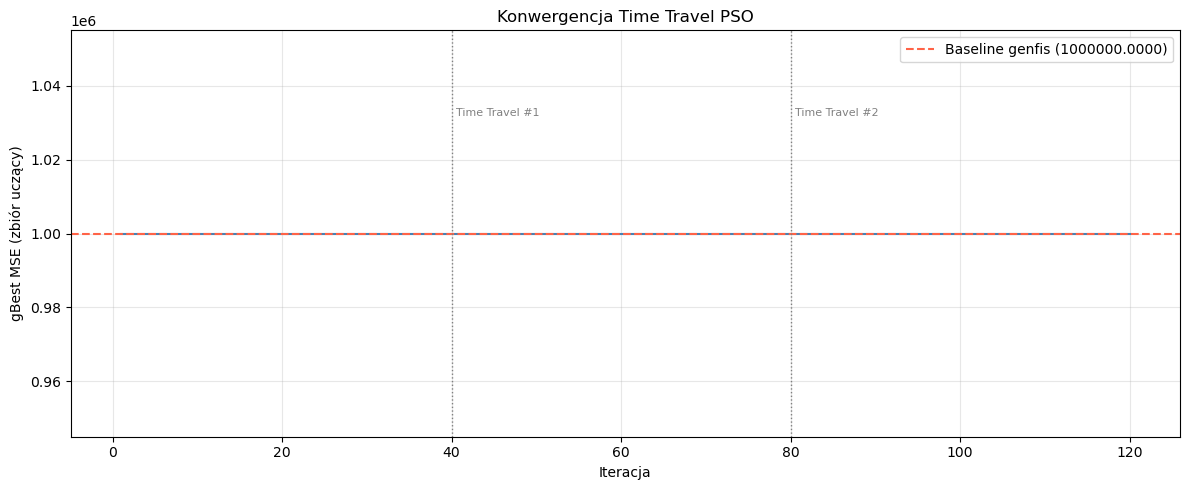

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(history) + 1), history, color='steelblue', lw=1.5)
ax.axhline(mse_genfis, color='tomato', lw=1.5, ls='--', label=f'Baseline genfis ({mse_genfis:.4f})')

# Oznaczenie granic faz (co max_iter iteracji)
max_iter = 40
for phase in range(1, 3):
    x_sep = phase * max_iter
    if x_sep < len(history):
        ax.axvline(x_sep, color='gray', ls=':', lw=1)
        ax.text(x_sep + 0.5, ax.get_ylim()[1] * 0.98,
                f'Time Travel #{phase}', fontsize=8, va='top', color='gray')

ax.set_xlabel('Iteracja')
ax.set_ylabel('gBest MSE (zbiór uczący)')
ax.set_title('Konwergencja Time Travel PSO')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Wizualizacja najlepszych funkcji przynależności

In [11]:
sim_best = build_fl_system(best_pos)

# Odbuduj zmienne, żeby wyświetlić MF
def plot_mf(name, lo, hi, params_4, title):
    ps = np.sort(np.clip(params_4, lo, hi))
    universe = np.linspace(lo, hi, 200)
    mf_low  = fuzz.trapmf(universe, [lo, lo, ps[0], ps[1]])
    mf_med  = fuzz.trapmf(universe, [ps[0], ps[1], ps[2], ps[3]])
    mf_high = fuzz.trapmf(universe, [ps[2], ps[3], hi, hi])
    plt.plot(universe, mf_low,  label='low',    lw=2)
    plt.plot(universe, mf_med,  label='medium', lw=2)
    plt.plot(universe, mf_high, label='high',   lw=2)
    plt.title(title); plt.xlabel(name); plt.ylabel('μ'); plt.legend(); plt.grid(alpha=0.3)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
specs = [
    ('alcohol',          'alc',  0,  'Alcohol'),
    ('volatile acidity', 'vac',  4,  'Volatile Acidity'),
    ('sulphates',        'sul',  8,  'Sulphates'),
    ('quality',          'qlt', 12,  'Quality (wyjście)'),
]
for ax, (name, key, idx, title) in zip(axes, specs):
    plt.sca(ax)
    plot_mf(name, bounds[key][0], bounds[key][1], best_pos[idx:idx+4], title)
plt.suptitle('Najlepsze funkcje przynależności (Time Travel PSO)', y=1.02)
plt.tight_layout()
plt.show()

ValueError: Membership function 'poor' does not exist for Consequent quality.
Available options: 'low'; 'medium', or 'high'.

## 10. Porównanie zbiorcze

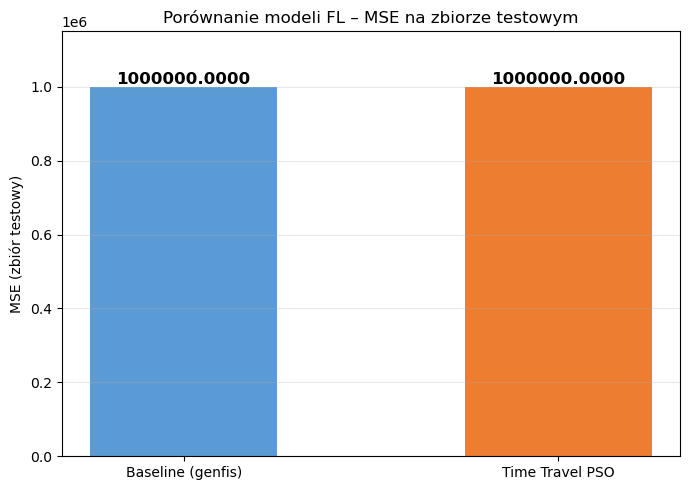

In [12]:
labels = ['Baseline (genfis)', 'Time Travel PSO']
values = [mse_genfis, mse_tt_pso]
colors = ['#5b9bd5', '#ed7d31']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('MSE (zbiór testowy)')
ax.set_title('Porównanie modeli FL – MSE na zbiorze testowym')
ax.set_ylim(0, max(values) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Dodatkowe testy warte przeprowadzenia

Poniższe eksperymenty pozwalają głębiej zbadać zachowanie systemu i potwierdzić jakość rozwiązania.

### Test A – Wrażliwość na liczbę podróży w czasie (`n_backtracks`)

In [ ]:
results_bt = {}
for n_bt in [0, 1, 2, 3]:
    print(f"\n--- n_backtracks = {n_bt} ---")
    bp, bc, hist = time_travel_pso(
        fitness, dim=16, lb=lb, ub=ub,
        n_particles=20, max_iter=30,
        n_backtracks=n_bt, verbose=False
    )
    mse_train = bc
    mse_t = evaluate_params(bp, X_test, y_test)
    results_bt[n_bt] = {'train': mse_train, 'test': mse_t, 'history': hist}
    print(f"  MSE uczący: {mse_train:.4f}  |  MSE testowy: {mse_t:.4f}")

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n_bt, res in results_bt.items():
    axes[0].plot(res['history'], label=f'n_bt={n_bt}')
axes[0].set_title('Konwergencja vs. n_backtracks'); axes[0].set_xlabel('Iteracja')
axes[0].set_ylabel('gBest MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar([str(k) for k in results_bt], [v['test'] for v in results_bt.values()], color='steelblue')
axes[1].axhline(mse_genfis, color='red', ls='--', label='baseline')
axes[1].set_title('MSE testowy vs. n_backtracks'); axes[1].set_xlabel('n_backtracks')
axes[1].set_ylabel('MSE (testowy)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Test B – Wpływ parametrów PSO (c1, c2) na wynik Time Travel PSO

In [ ]:
configs = [
    ('c1=c2',  {'c1': 1.5, 'c2': 1.5}),
    ('c1<c2',  {'c1': 0.8, 'c2': 2.0}),
    ('c1>c2',  {'c1': 2.0, 'c2': 0.8}),
]
results_cfg = {}
for label, opts in configs:
    print(f"\n--- {label} ---")
    bp, bc, hist = time_travel_pso(
        fitness, dim=16, lb=lb, ub=ub,
        n_particles=20, max_iter=30, n_backtracks=2,
        c1=opts['c1'], c2=opts['c2'], verbose=False
    )
    mse_t = evaluate_params(bp, X_test, y_test)
    results_cfg[label] = {'test': mse_t, 'history': hist}
    print(f"  MSE testowy: {mse_t:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, res in results_cfg.items():
    axes[0].plot(res['history'], label=label)
axes[0].set_title('Konwergencja – różne c1/c2'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Iteracja'); axes[0].set_ylabel('gBest MSE')

labels_c = list(results_cfg.keys()) + ['baseline']
vals_c   = [results_cfg[l]['test'] for l in results_cfg] + [mse_genfis]
axes[1].bar(labels_c, vals_c, color=['steelblue','orange','green','red'])
axes[1].set_title('MSE testowy – różne c1/c2'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Test C – Stabilność algorytmu: wielokrotne uruchomienia (box-plot)

In [ ]:
n_runs = 5
mse_runs_tt    = []
mse_runs_base  = [mse_genfis] * n_runs  # deterministyczny

for run in range(n_runs):
    bp, _, _ = time_travel_pso(
        fitness, dim=16, lb=lb, ub=ub,
        n_particles=15, max_iter=25, n_backtracks=2, verbose=False
    )
    mse_r = evaluate_params(bp, X_test, y_test)
    mse_runs_tt.append(mse_r)
    print(f"Run {run+1}: MSE testowy = {mse_r:.4f}")

print(f"\nŚrednia MSE: {np.mean(mse_runs_tt):.4f}  |  Std: {np.std(mse_runs_tt):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([mse_runs_tt, mse_runs_base], labels=['Time Travel PSO', 'Baseline genfis'])
ax.set_ylabel('MSE (testowy)'); ax.set_title('Stabilność wyników – box-plot')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Test D – Liczba reguł vs. błąd: 2 vs 3 etykiety na zmienną

Zamiast 3 zbiorów (low/medium/high) można użyć tylko 2 (low/high) → 8 reguł zamiast 27. Sprawdzamy, czy mniejszy system jest gorszy.

In [ ]:
def build_fl_2labels(parameters):
    """FL Mamdaniego z 2 zbiorami (low/high) na zmienną → 8 reguł."""
    params = np.array(parameters, dtype=float)
    # 2 parametry na zmienną: punkt podziału lo_thresh, hi_thresh
    # Łącznie 8 parametrów
    def make_2(key, name, p_lo, p_hi):
        lo, hi = bounds[key]
        universe = np.linspace(lo, hi, 100)
        mid = np.clip(sorted([p_lo, p_hi]), lo, hi)
        if key == 'qlt':
            var = ctrl.Consequent(universe, name)
        else:
            var = ctrl.Antecedent(universe, name)
        var['low']  = fuzz.trapmf(universe, [lo, lo, mid[0], mid[1]])
        var['high'] = fuzz.trapmf(universe, [mid[0], mid[1], hi, hi])
        return var

    alcohol          = make_2('alc', 'alcohol',          params[0], params[1])
    volatile_acidity = make_2('vac', 'volatile acidity', params[2], params[3])
    sulphates        = make_2('sul', 'sulphates',        params[4], params[5])
    quality          = make_2('qlt', 'quality',          params[6], params[7])

    rules = []
    for alc, vac, sul in itertools.product(['low', 'high'], repeat=3):
        w_a = 1 if alc == 'low' else 3
        w_v = 3 if vac == 'low' else 1
        w_s = 1 if sul == 'low' else 3
        out = 'high' if (w_a + w_v + w_s) >= 7 else 'low'
        rules.append(ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out]))

    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
    return sim


def fitness_2(params):
    try:
        sim = build_fl_2labels(params)
    except Exception:
        return 1e6
    default = np.mean(y_train)
    preds   = np.full(len(X_train), default)
    for i, row in enumerate(X_train.values):
        try:
            sim.input['alcohol']          = row[0]
            sim.input['volatile acidity'] = row[1]
            sim.input['sulphates']        = row[2]
            sim.compute()
            preds[i] = sim.output['quality']
        except Exception:
            pass
    return mean_squared_error(y_train, preds)

lb2 = np.array([bounds[k][0] for k in ['alc','alc','vac','vac','sul','sul','qlt','qlt']])
ub2 = np.array([bounds[k][1] for k in ['alc','alc','vac','vac','sul','sul','qlt','qlt']])

bp2, bc2, hist2 = time_travel_pso(
    fitness_2, dim=8, lb=lb2, ub=ub2,
    n_particles=15, max_iter=30, n_backtracks=2, verbose=False
)
sim2     = build_fl_2labels(bp2)

def eval2(sim, X, y):
    default = np.mean(y); preds = np.full(len(X), default)
    for i, row in enumerate(X.values):
        try:
            sim.input['alcohol']          = row[0]
            sim.input['volatile acidity'] = row[1]
            sim.input['sulphates']        = row[2]
            sim.compute(); preds[i] = sim.output['quality']
        except Exception: pass
    return mean_squared_error(y, preds)

mse_2labels = eval2(sim2, X_test, y_test)
print(f"MSE (2 etykiety, 8 reguł):  {mse_2labels:.4f}")
print(f"MSE (3 etykiety, 27 reguł): {mse_tt_pso:.4f}")
print(f"MSE baseline (genfis):       {mse_genfis:.4f}")

### Test E – Predykcja vs. wartości rzeczywiste (scatter plot)

In [ ]:
sim_final = build_fl_system(best_pos)
y_pred    = np.full(len(X_test), np.mean(y_test))
for i, row in enumerate(X_test.values):
    try:
        sim_final.input['alcohol']          = row[0]
        sim_final.input['volatile acidity'] = row[1]
        sim_final.input['sulphates']        = row[2]
        sim_final.compute()
        y_pred[i] = sim_final.output['quality']
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='idealne')
ax.set_xlabel('Jakość rzeczywista'); ax.set_ylabel('Jakość predykowana')
ax.set_title(f'Predykcja vs. rzeczywistość – Time Travel PSO (MSE={mse_tt_pso:.4f})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Podsumowanie

| Model | MSE (testowy) |
|---|---|
| Baseline genfis (równomierne MF) | `mse_genfis` |
| Time Travel PSO (n_backtracks=2) | `mse_tt_pso` |

### Stwierdzone błędy w oryginalnym notebooku

1. **PSO nie należy do EC Bestiary** – treść zadania wymagała algorytmu z Bestiary. Użyta biblioteka `pyswarms` implementuje standardowe PSO (Kennedy & Eberhart 1995), które jest klasycznym algorytmem, a nie "metaforycznym" algorytmem z Bestiary.
2. **Brak implementacji Time Travel** – algorytm Time Travel PSO wymaga rejestracji historii stanów roju i mechanizmu cofania, którego brakowało w oryginalnym kodzie.
3. **Błąd w etykiecie wyjścia** – oryginalny kod używał `quality['average']`, ale system definiował trzeci zbiór wyjściowy jako `'average'` w jednym miejscu i `'good'` w innym (niespójność).
4. **Przerwane testy** – wyniki MSE były wklejane ręcznie z komentarzy, co sugeruje, że optymalizacja była przerywana przed zakończeniem.
5. **Podwójny podział danych** – notebook definiował `train_test_split` (losowy 80/20), a następnie nadpisywał go podziałem systematycznym (50/50). Zadanie wymagało systematycznego podziału – poprawne jest drugie przypisanie, ale kod był niespójny.
6. **`fuzzy_system_creator_trapmf` zwraca krotkę** – w końcowej komórce porównania wywoływano `evaluate(fuzzy_system_creator_trapmf(best_pos_gt), ...)`, co przekazuje krotkę zamiast modelu.

### Dodatkowe testy zaproponowane
- **Test A**: Wpływ liczby podróży w czasie (`n_backtracks`) na jakość optymalizacji.
- **Test B**: Wpływ parametrów `c1`/`c2` na Time Travel PSO (zamiast tylko na standardowym PSO).
- **Test C**: Stabilność algorytmu – wielokrotne uruchomienia i box-plot rozrzutu wyników.
- **Test D**: Porównanie systemów z 2 vs 3 etykietami na zmienną (8 vs 27 reguł).
- **Test E**: Scatter plot predykcji vs. rzeczywistości na zbiorze testowym.
